In [ ]:
!pip install ultralytics

In [35]:
from PIL import Image
from ultralytics import YOLO
import numpy as np

In [40]:
def get_cropped_faces(filenames):
    """
    filenames: list of filename

    Return:
        [[file1_cropped_face1, file1_cropped_face2, ...], [file2_cropped_face1, ...], ...]
    """
    yolov8_animeface = YOLO('Model/yolov8x6_animeface.pt')
    results = yolov8_animeface.predict(filenames, save=False, conf=0.3, iou=0.5)
    bounding_boxes = get_bounding_boxes(results)
    cropped_faces = []
    for filename, boxes in zip(filenames, bounding_boxes):
        file_cropped_faces = []
        for box in boxes:
            cropped = get_cropped(filename, box)
            file_cropped_faces.append(cropped)
        cropped_faces.append(file_cropped_faces)
    return cropped_faces

# Helper Functions
def get_bounding_boxes(results):
    """
    Input
        results: list of list of detected output
    
    Return
        List of list of dicts
    """
    out = []
    for result in results:
        boxes = result.boxes
        bounding_boxes = []
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()  # top-left and bottom-right corners
            # confidence = box.conf[0].item()
            
            bound_box = np.array([[x1, y1],
                                  [x2, y2]])
            bounding_boxes.append(bound_box)
        out.append(bounding_boxes)
    return out


def get_cropped(filename, bounding_box):
    """
    Input
        filename: image file name (str)
        top_left: location of top-left corner (len-2 tuple: (x1, y1))
        bottom_right: location of bottom_right corner (len-2 tuple: (x2, y2))
    
    Return
        cropped img
    """
    img = Image.open(filename)

    top_left = bounding_box[0, :]
    bottom_right = bounding_box[1, :]
    # Pillow crop takes (left, upper, right, lower)
    cropped = img.crop((top_left[0], top_left[1], bottom_right[0], bottom_right[1]))
    return cropped

In [34]:
yolov8_animeface = YOLO('Model/yolov8x6_animeface.pt')
results = yolov8_animeface.predict('Manga109/images/AisazuNihaIrarenai/002.jpg', save=True, conf=0.3, iou=0.5)
for result in results:
    boxes = result.boxes
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()  # top-left and bottom-right corners
        confidence = box.conf[0].item()
        
        print(f"Face detected:")
        print(f"  Top-left:     ({x1:.1f}, {y1:.1f})")
        print(f"  Bottom-right: ({x2:.1f}, {y2:.1f})")
        print(f"  Width:        {x2 - x1:.1f}px")
        print(f"  Height:       {y2 - y1:.1f}px")
        print(f"  Confidence:   {confidence:.2f}")
        print()


image 1/1 /Users/nathan/Library/Mobile Documents/com~apple~CloudDocs/1-MIT/Spring 2026/6.S058/6.s058-Project/Manga109/images/AisazuNihaIrarenai/002.jpg: 960x1280 5 faces, 1801.9ms
Speed: 4.4ms preprocess, 1801.9ms inference, 0.8ms postprocess per image at shape (1, 3, 960, 1280)
Results saved to /Users/nathan/Library/Mobile Documents/com~apple~CloudDocs/1-MIT/Spring 2026/6.S058/6.s058-Project/runs/detect/predict
Face detected:
  Top-left:     (1011.4, 247.9)
  Bottom-right: (1148.2, 366.7)
  Width:        136.8px
  Height:       118.7px
  Confidence:   0.58

Face detected:
  Top-left:     (1020.3, 995.1)
  Bottom-right: (1046.3, 1020.2)
  Width:        26.0px
  Height:       25.1px
  Confidence:   0.57

Face detected:
  Top-left:     (1512.9, 921.0)
  Bottom-right: (1534.4, 945.6)
  Width:        21.5px
  Height:       24.6px
  Confidence:   0.40

Face detected:
  Top-left:     (481.3, 896.2)
  Bottom-right: (587.5, 988.8)
  Width:        106.2px
  Height:       92.6px
  Confidence:  


0: 960x1280 5 faces, 1883.2ms
Speed: 7.3ms preprocess, 1883.2ms inference, 0.9ms postprocess per image at shape (1, 3, 960, 1280)


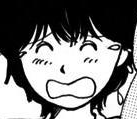

In [41]:
get_cropped_faces(['Manga109/images/AisazuNihaIrarenai/002.jpg'])[0][0]

In [ ]:
def compute_iou(box1, box2):
    """
    box1, box2: np.array([[xmin, ymin], [xmax, ymax]])
    """
    x1 = max(box1[0, 0], box2[0, 0])
    y1 = max(box1[0, 1], box2[0, 1])
    x2 = min(box1[1, 0], box2[1, 0])
    y2 = min(box1[1, 1], box2[1, 1])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[1, 0] - box1[0, 0]) * (box1[1, 1] - box1[0, 1])
    area2 = (box2[1, 0] - box2[0, 0]) * (box2[1, 1] - box2[0, 1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0.0


def get_best_iou(detected_box, annotated_boxes):
    """Return the best IoU match for a detected box against all annotated boxes."""
    return max(compute_iou(detected_box, ann) for ann in annotated_boxes)

In [ ]:
for result in results:
    boxes = result.boxes
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()  # top-left and bottom-right corners
        confidence = box.conf[0].item()
        
        print(f"Face detected:")
        print(f"  Top-left:     ({x1:.1f}, {y1:.1f})")
        print(f"  Bottom-right: ({x2:.1f}, {y2:.1f})")
        print(f"  Width:        {x2 - x1:.1f}px")
        print(f"  Height:       {y2 - y1:.1f}px")
        print(f"  Confidence:   {confidence:.2f}")
        print()